In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
DATASET PREPROCESSING — Rasm sifatini yaxshilash
Hal qilinadigan muammolar:
  1. Qora chegara kesish (black border crop)
  2. Doiraviy mikroskop rasmidan ichini olish
  3. Kontrast oshirish (CLAHE)
  4. Standart o'lchamga keltirish (320x320)
  5. Natija papkaga saqlash

Ishlatish:
  python preprocess_dataset.py
"""

import os
import cv2
import numpy as np
from pathlib import Path
import shutil

# ─────────────────────────────────────
# SOZLAMALAR
# ─────────────────────────────────────
INPUT_DIR  = './Qon tahlili'          # Asl dataset
OUTPUT_DIR = 'Qon tahlili_clean'    # Tozalangan dataset
TARGET_SIZE = 320                     # Kvadrat o'lcham
IMG_EXTS    = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

CLASS_NAMES = [
    'Eritrosit',
    'Healthy blood cell',
    'Leykotsit',
    'Noodatiy hujayralar',
    'Trombosit'
]

In [ ]:
# ============================================================
# KONSTANTALAR
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
NUM_CLASSES = 5

CLASS_NAMES = [
    'Eritrosit',
    'Healthy blood cell',
    'Leykotsit',
    'Noodatiy hujayralar',
    'Trombosit'
]

# Normal qiymatlar (Image 8 dan)
NORMAL_RANGES = {
    'Eritrosit':           {'Erkaklar': '4.5–5.9×10¹²/L', 'Ayollar': '4.0–5.2×10¹²/L', 'Bolalar': '4.0–5.0×10¹²/L'},
    'Leykotsit':           {'Erkaklar': '4.0–9.0×10⁹/L',  'Ayollar': '4.0–9.0×10⁹/L',  'Bolalar': '5.0–14.0×10⁹/L'},
    'Trombosit':           {'Erkaklar': '150–400×10⁹/L',   'Ayollar': '150–400×10⁹/L',   'Bolalar': '150–450×10⁹/L'},
    'Healthy blood cell':  {'Erkaklar': 'Mavjud',           'Ayollar': 'Mavjud',            'Bolalar': 'Mavjud'},
    'Noodatiy hujayralar': {'Erkaklar': "Yo'q",             'Ayollar': "Yo'q",              'Bolalar': "Yo'q"},
}

DATA_DIR = "/content/drive/MyDrive/Qon tahlili"  # train/val/test papkalari shu joyda

In [ ]:
# ============================================================
# MODEL ARXITEKTURASI (EfficientNetB0 + custom head)
# ============================================================
def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # Birinchi bosqichda freeze

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [ ]:
# ============================================================
# DATA GENERATORLAR
# ============================================================
def get_generators(data_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest',
        validation_split=0.2  # Добавляем разделение для валидации
    )

    # val_datagen больше не нужен, так как train_datagen теперь будет обрабатывать разделение
    # val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        data_dir, # Изменено: теперь указываем DATA_DIR напрямую
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='training', # Указываем, что это подмножество для обучения
        shuffle=True
    )

    val_gen = train_datagen.flow_from_directory( # Используем тот же datagen, но для валидации
        data_dir, # Изменено: теперь указываем DATA_DIR напрямую
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='validation', # Указываем, что это подмножество для валидации
        shuffle=False
    )

    return train_gen, val_gen

In [ ]:
# ============================================================
# TRENING
# ============================================================
def train(data_dir=DATA_DIR, save_path='blood_cell_model.h5'):
    print("=" * 60)
    print("QON HUJAYRALARI TASNIFLAGICH - TRENING")
    print("=" * 60)

    train_gen, val_gen = get_generators(data_dir)

    print(f"\nSinflar: {train_gen.class_indices}")
    print(f"Trening rasmlari: {train_gen.samples}")
    print(f"Validatsiya rasmlari: {val_gen.samples}\n")

    model, base_model = build_model()

    # Bosqich 1: Faqat head layer
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
    ]

    print("Bosqich 1: Head layer trening...")
    history1 = model.fit(
        train_gen,
        epochs=20,
        validation_data=val_gen,
        callbacks=callbacks
    )

    # Bosqich 2: Fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\nBosqich 2: Fine-tuning...")
    history2 = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks
    )

    # Metadata h5 faylga yozish
    save_metadata_to_h5(save_path)

    print(f"\n✅ Model saqlandi: {save_path}")
    plot_history(history1, history2)
    return model

In [ ]:
# ============================================================
# H5 FAYLGA METADATA YOZISH
# ============================================================
def save_metadata_to_h5(h5_path):
    """Model.h5 faylga sinf nomlari va normal diapazonlarni yozish"""
    with h5py.File(h5_path, 'a') as f:
        meta = f.require_group('metadata')
        meta.attrs['class_names'] = json.dumps(CLASS_NAMES)
        meta.attrs['normal_ranges'] = json.dumps(NORMAL_RANGES)
        meta.attrs['img_size'] = IMG_SIZE
        meta.attrs['num_classes'] = NUM_CLASSES
        meta.attrs['version'] = '1.0'
    print("✅ Metadata h5 faylga yozildi")

QON HUJAYRALARI TASNIFLAGICH - TRENING
Found 5590 images belonging to 5 classes.
Found 1395 images belonging to 5 classes.

Sinflar: {'Eritrosit': 0, 'Healthy blood cell': 1, 'Leykotsit': 2, 'Noodatiy hujayralar': 3, 'Trombosit': 4}
Trening rasmlari: 5590
Validatsiya rasmlari: 1395

Bosqich 1: Head layer trening...
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3463 - loss: 1.7486
Epoch 1: val_accuracy improved from None to 0.35986, saving model to blood_cell_model.h5



Epoch 1: finished saving model to blood_cell_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 3526s 10s/step - accuracy: 0.3386 - loss: 1.6939 - val_accuracy: 0.3599 - val_loss: 1.5145 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3392 - loss: 1.5254
Epoch 2: val_accuracy did not improve from 0.35986
350/350 ━━━━━━━━━━━━━━━━━━━━ 541s 2s/step - accuracy: 0.3499 - loss: 1.4779 - val_accuracy: 0.3599 - val_loss: 1.5182 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3432 - loss: 1.4066
Epoch 3: val_accuracy improved from 0.35986 to 0.53262, saving model to blood_cell_model.h5



Epoch 3: finished saving model to blood_cell_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.3551 - loss: 1.3809 - val_accuracy: 0.5326 - val_loss: 1.4819 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3732 - loss: 1.3321
Epoch 4: val_accuracy did not improve from 0.53262
350/350 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.3717 - loss: 1.3410 - val_accuracy: 0.5183 - val_loss: 1.4346 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3922 - loss: 1.3279
Epoch 5: val_accuracy did not improve from 0.53262
350/350 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.3878 - loss: 1.3263 - val_accuracy: 0.3570 - val_loss: 1.4344 - learning_rate: 0.0010
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3866 - loss: 1.3156
Epoch 6: val_accuracy did not improve from 0.53262
350/350 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.3830 - loss: 1.3160 - val_accuracy: 0.3556 - val_loss: 

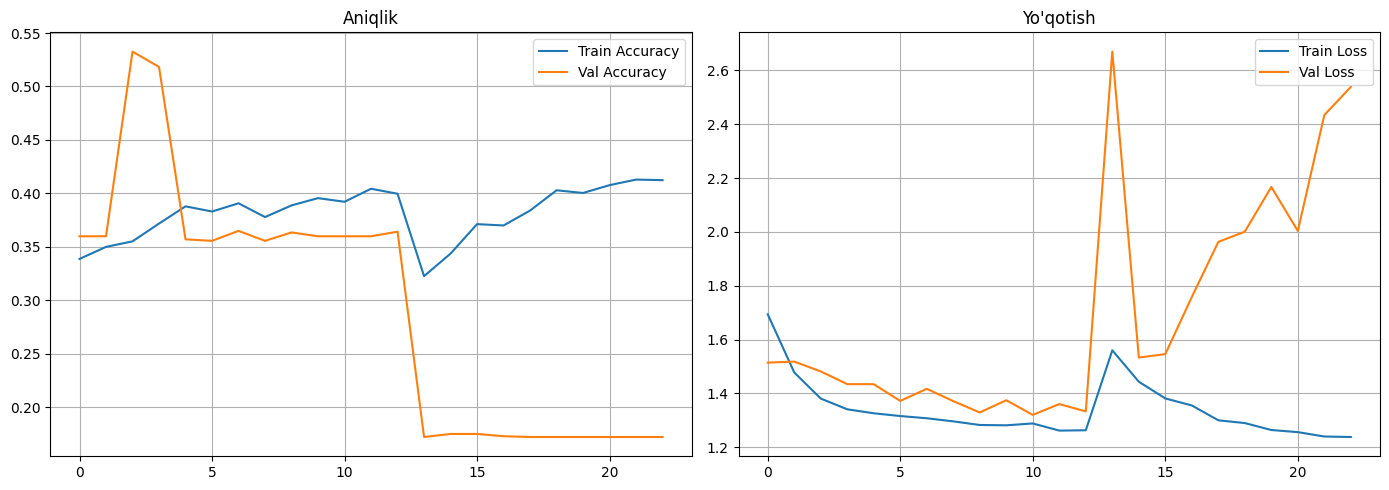

In [ ]:
# ============================================================
# GRAFIK
# ============================================================
def plot_history(*histories):
    all_acc, all_val_acc = [], []
    all_loss, all_val_loss = [], []
    for h in histories:
        all_acc.extend(h.history['accuracy'])
        all_val_acc.extend(h.history['val_accuracy'])
        all_loss.extend(h.history['loss'])
        all_val_loss.extend(h.history['val_loss'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(all_acc, label='Train Accuracy')
    axes[0].plot(all_val_acc, label='Val Accuracy')
    axes[0].set_title('Aniqlik')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(all_loss, label='Train Loss')
    axes[1].plot(all_val_loss, label='Val Loss')
    axes[1].set_title('Yo\'qotish')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    print("✅ Trening grafigi saqlandi: training_history.png")
    plt.show()


if __name__ == '__main__':
    train(data_dir=DATA_DIR, save_path='blood_cell_model.h5')

In [ ]:
import os

print(f"Содержимое {DATA_DIR}:")
for item in os.listdir(DATA_DIR):
    item_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(item_path):
        print(f"  [Папка] {item}")
    else:
        print(f"  [Файл] {item}")

In [ ]:
import os

print(f"Содержимое {DATA_DIR}:")
for item in os.listdir(DATA_DIR):
    item_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(item_path):
        print(f"  [Папка] {item}")
    else:
        print(f"  [Файл] {item}")

Содержимое /content/drive/MyDrive/Qon tahlili:
  [Папка] Healthy blood cell
  [Папка] Leykotsit
  [Папка] Noodatiy hujayralar
  [Папка] Trombosit
  [Папка] Eritrosit


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/Qon tahlili",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/Qon tahlili",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 5590 images belonging to 5 classes.
Found 1395 images belonging to 5 classes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(5,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(5,activation='softmax') # Changed from 3 to 5 to match the 5 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

model.save("blood_cells_classifier.h5")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5642 - loss: 0.8505

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


350/350 ━━━━━━━━━━━━━━━━━━━━ 2427s 7s/step - accuracy: 0.5644 - loss: 0.8499 - val_accuracy: 0.6409 - val_loss: 0.5363
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 238s 678ms/step - accuracy: 0.6525 - loss: 0.5403 - val_accuracy: 0.6366 - val_loss: 0.5353
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 264s 684ms/step - accuracy: 0.6821 - loss: 0.4980 - val_accuracy: 0.7211 - val_loss: 0.4862
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 257s 734ms/step - accuracy: 0.7451 - loss: 0.4649 - val_accuracy: 0.8072 - val_loss: 0.3762
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 260s 743ms/step - accuracy: 0.8193 - loss: 0.3643 - val_accuracy: 0.8588 - val_loss: 0.2909
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 257s 736ms/step - accuracy: 0.8752 - loss: 0.2567 - val_accuracy: 0.9032 - val_loss: 0.2340
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 247s 705ms/step - accuracy: 0.9484 - loss: 0.1309 - val_accuracy: 0.9742 - val_loss: 0.0866
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 257s 689ms/step - accuracy: 0.9595 - loss: 0.1098

In [ ]:
from tensorflow.keras.models import load_model
import cv2, numpy as np
import os

model = load_model("blood_cells_classifier.h5")

classes = list(train_gen.class_indices.keys())
counts = dict.fromkeys(classes,0)

In [ ]:
#test kodi
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Modelni yuklash
model = load_model("blood_cells_classifier.h5")

# Sinf nomlari (datasetdagi papka nomlari bilan bir xil bo‘lishi kerak)
classes = [
    "Eritrosit",
    "Healthy blood cell",
    "Leykotsit",
    "Trombosit",
    "Noodatiy hujayralar"
]

# Har bir sinf uchun sanagich
counts = {c:0 for c in classes}

# Test rasmlar papkasi
test_folder = "test_images"

# Collect all image file paths from the test_folder and its subdirectories
image_paths = []
for root, _, files in os.walk(test_folder):
    for file in files:
        # Check for common image file extensions
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_paths.append(os.path.join(root, file))

for path in image_paths:
    img = cv2.imread(path)
    if img is not None: # Check if the image was loaded successfully
        img = cv2.resize(img,(128,128))
        img = img/255.0
        img = np.expand_dims(img, axis=0)

        pred = model.predict(img, verbose=0)

        class_index = np.argmax(pred)
        label = classes[class_index]

        counts[label] += 1
    else:
        print(f"Warning: Could not load image {path}. Skipping.")

# -------------------------------
# Natijani chiqarish
# -------------------------------

total = sum(counts.values())

print("\n====== NATIJA ======\n")

for k,v in counts.items():

    percent = (v/total)*100 if total>0 else 0

    print(f"{k}: {v} ta   ({percent:.2f}%)")

print("\nJami rasmlar:", total)



====== NATIJA ======

Eritrosit: 12 ta   (48.00%)
Healthy blood cell: 5 ta   (20.00%)
Leykotsit: 0 ta   (0.00%)
Trombosit: 8 ta   (32.00%)
Noodatiy hujayralar: 0 ta   (0.00%)

Jami rasmlar: 25
